# Assignment 4: Training a DCGAN on Fashion MNIST Dataset

## Objective

The objective of this assignment is to understand how a Deep Convolutional Generative Adversarial Network (DCGAN) is trained and how the Generator and Discriminator improve over time.

### Requirements
- Fashion-MNIST dataset
- PyTorch implementation
- Generator using transposed convolution layers
- Discriminator using convolution layers
- Train for 30 epochs
- Save a 4 × 4 grid of generated images every 5 epochs
- Record Generator and Discriminator losses
- Plot both losses
- Analyze the generated images at different stages of training

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Basic parameters
batch_size = 128
latent_dim = 100
learning_rate = 0.0002
epochs = 25

#  noise vector
torch.manual_seed(42)

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

print("Noise vector shape:", fixed_noise.shape)

Using device: cuda
Noise vector shape: torch.Size([16, 100, 1, 1])


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of images:", len(train_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.5MB/s]

Number of images: 60000


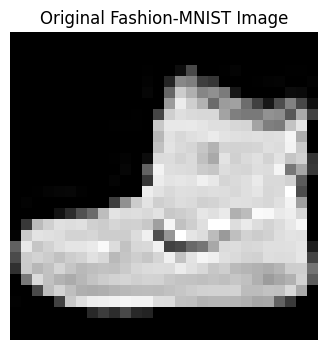

In [5]:
image, label = train_dataset[0]

# [-1, 1] to [0, 1]
image = (image + 1) / 2

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original Fashion-MNIST Image")
plt.axis("off")
plt.show()

#Building the Generator

In [6]:
class Generator(nn.Module):

    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # Random noise: 100 x 1 x 1
            # Output: 128 x 7 x 7
            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 7 x 7 -> 14 x 14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 14 x 14 -> 28 x 28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # Final output between -1 and +1
            nn.Tanh()
        )

    def forward(self, noise):
        return self.model(noise)

In [7]:
generator = Generator(latent_dim).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)


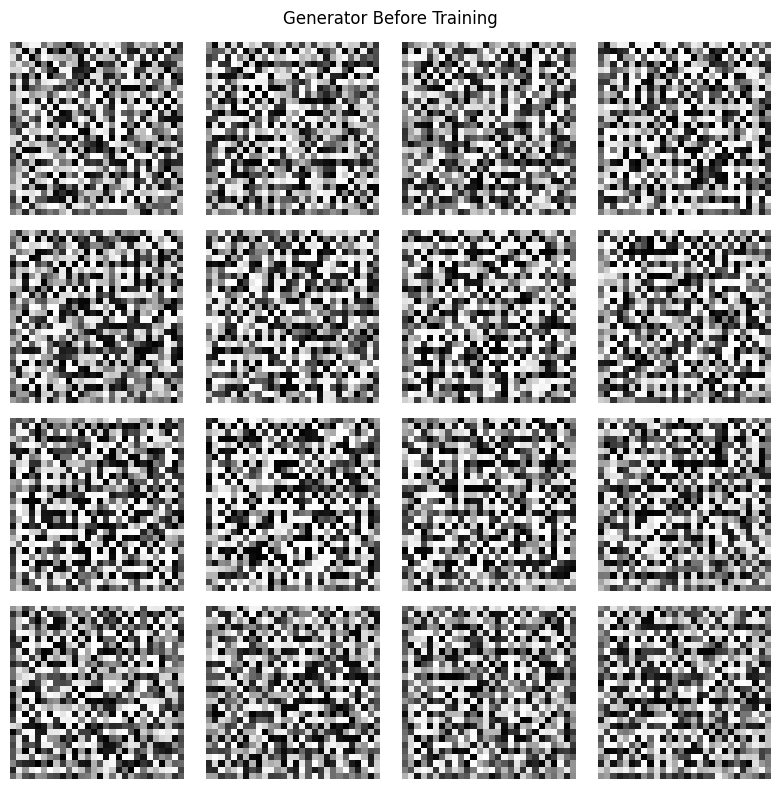

In [8]:
with torch.no_grad():
    generated_images = generator(fixed_noise)

# Display generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):

    image = generated_images[i].cpu()

    # [-1, 1] to [0, 1]
    image = (image + 1) / 2

    ax.imshow(image.squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("Generator Before Training")
plt.tight_layout()
plt.show()

#Building the Discriminator

In [9]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 28 x 28 -> 14 x 14
            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(0.2),

            # 14 x 14 -> 7 x 7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # 7 x 7 -> 1 x 1
            nn.Conv2d(
                128,
                1,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            # Real = 1
            # Fake = 0
            nn.Sigmoid()
        )

    def forward(self, image):
        return self.model(image).view(-1)

In [10]:
discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1))
    (6): Sigmoid()
  )
)


#Defining the Loss Functions and Optimizers

In [11]:
# Binary Cross-Entropy loss
criterion = nn.BCELoss()

# Optimizer for Generator
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

# Optimizer for Discriminator
optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

#Model Training

In [12]:
generator_losses = []
discriminator_losses = []

for epoch in range(1, epochs + 1):

    total_g_loss = 0
    total_d_loss = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(device)

        batch_size_current = real_images.size(0)

        # Labels
        real_labels = torch.ones(
            batch_size_current,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size_current,
            device=device
        )

        # 1. Train Discriminator

        optimizer_D.zero_grad()

        # Discriminator classifies real images
        real_output = discriminator(real_images)

        real_loss = criterion(
            real_output,
            real_labels
        )

        # Generate fake images
        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        # Discriminator classifies fake images
        fake_output = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        # Total Discriminator loss
        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # 2. Train Generator

        optimizer_G.zero_grad()

        # Generate new fake images
        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        # Discriminator evaluates fake images
        output = discriminator(fake_images)

        # Generator wants fake = real
        g_loss = criterion(
            output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    # Average losses
    avg_d_loss = total_d_loss / len(train_loader)
    avg_g_loss = total_g_loss / len(train_loader)

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    print(
        f"Epoch [{epoch}/{epochs}] | "
        f"Discriminator Loss: {avg_d_loss:.4f} | "
        f"Generator Loss: {avg_g_loss:.4f}"
    )

Epoch [1/25] | Discriminator Loss: 0.6751 | Generator Loss: 1.7014
Epoch [2/25] | Discriminator Loss: 0.8484 | Generator Loss: 1.3611
Epoch [3/25] | Discriminator Loss: 0.9728 | Generator Loss: 1.1989
Epoch [4/25] | Discriminator Loss: 1.0228 | Generator Loss: 1.1376
Epoch [5/25] | Discriminator Loss: 1.0247 | Generator Loss: 1.1539
Epoch [6/25] | Discriminator Loss: 1.0260 | Generator Loss: 1.1550
Epoch [7/25] | Discriminator Loss: 1.0274 | Generator Loss: 1.1519
Epoch [8/25] | Discriminator Loss: 1.0317 | Generator Loss: 1.1624
Epoch [9/25] | Discriminator Loss: 1.0240 | Generator Loss: 1.1668
Epoch [10/25] | Discriminator Loss: 1.0185 | Generator Loss: 1.1844
Epoch [11/25] | Discriminator Loss: 1.0094 | Generator Loss: 1.1834
Epoch [12/25] | Discriminator Loss: 1.0095 | Generator Loss: 1.2043
Epoch [13/25] | Discriminator Loss: 0.9986 | Generator Loss: 1.2107
Epoch [14/25] | Discriminator Loss: 0.9961 | Generator Loss: 1.2282
Epoch [15/25] | Discriminator Loss: 0.9893 | Generator Lo

In [13]:
# Store generated images from every 5th epoch
saved_images = {}

# Train again while saving images every 5 epochs

#Final Training

In [14]:
generator_losses = []
discriminator_losses = []

# Store generated images from every 5th epoch
saved_images = {}

for epoch in range(1, epochs + 1):

    total_g_loss = 0
    total_d_loss = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(device)

        current_batch_size = real_images.size(0)

        real_labels = torch.ones(
            current_batch_size,
            device=device
        )

        fake_labels = torch.zeros(
            current_batch_size,
            device=device
        )

        # Train Discriminator

        optimizer_D.zero_grad()

        real_output = discriminator(real_images)

        real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # Train Generator

        optimizer_G.zero_grad()

        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        output = discriminator(fake_images)

        # Generator classifies real images as fake
        g_loss = criterion(
            output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    # Calculate average losses
    avg_d_loss = total_d_loss / len(train_loader)
    avg_g_loss = total_g_loss / len(train_loader)

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    print(
        f"Epoch [{epoch}/{epochs}] | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    # Save images every 5 epochs

    if epoch % 5 == 0:

        generator.eval()

        with torch.no_grad():
            images = generator(fixed_noise).cpu()

        generator.train()

        saved_images[epoch] = images

Epoch [1/25] | D Loss: 0.9153 | G Loss: 1.3771
Epoch [2/25] | D Loss: 0.9054 | G Loss: 1.3963
Epoch [3/25] | D Loss: 0.8896 | G Loss: 1.4075
Epoch [4/25] | D Loss: 0.8892 | G Loss: 1.4296
Epoch [5/25] | D Loss: 0.8892 | G Loss: 1.4363
Epoch [6/25] | D Loss: 0.8781 | G Loss: 1.4416
Epoch [7/25] | D Loss: 0.8735 | G Loss: 1.4533
Epoch [8/25] | D Loss: 0.8672 | G Loss: 1.4744
Epoch [9/25] | D Loss: 0.8607 | G Loss: 1.4790
Epoch [10/25] | D Loss: 0.8573 | G Loss: 1.4960
Epoch [11/25] | D Loss: 0.8491 | G Loss: 1.5149
Epoch [12/25] | D Loss: 0.8495 | G Loss: 1.5336
Epoch [13/25] | D Loss: 0.8337 | G Loss: 1.5345
Epoch [14/25] | D Loss: 0.8344 | G Loss: 1.5444
Epoch [15/25] | D Loss: 0.8262 | G Loss: 1.5610
Epoch [16/25] | D Loss: 0.8253 | G Loss: 1.5751
Epoch [17/25] | D Loss: 0.8182 | G Loss: 1.5935
Epoch [18/25] | D Loss: 0.8131 | G Loss: 1.6010
Epoch [19/25] | D Loss: 0.8081 | G Loss: 1.6183
Epoch [20/25] | D Loss: 0.8039 | G Loss: 1.6244
Epoch [21/25] | D Loss: 0.8032 | G Loss: 1.6494
E

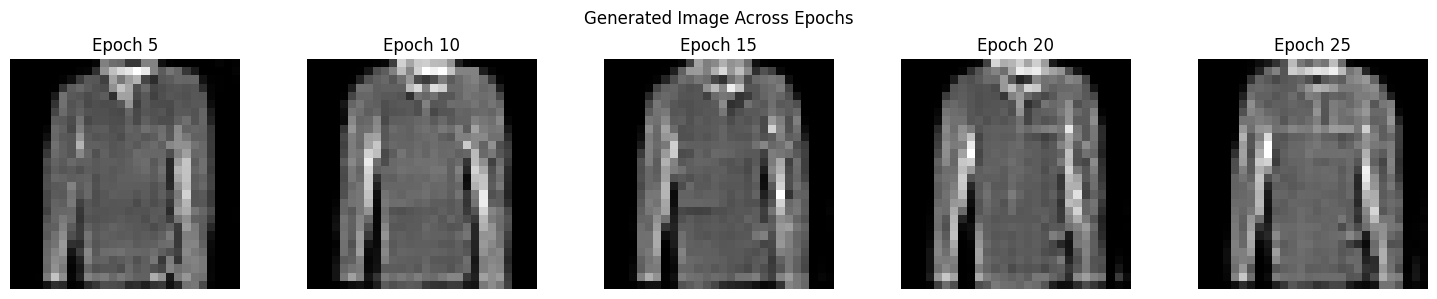

In [15]:
epochs_to_show = [5, 10, 15, 20, 25]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3)
)

for ax, epoch in zip(axes, epochs_to_show):

    images = saved_images[epoch]

    # Show the first generated image
    image = images[0]

    image = (image + 1) / 2

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.suptitle("Generated Image Across Epochs")
plt.tight_layout()
plt.show()

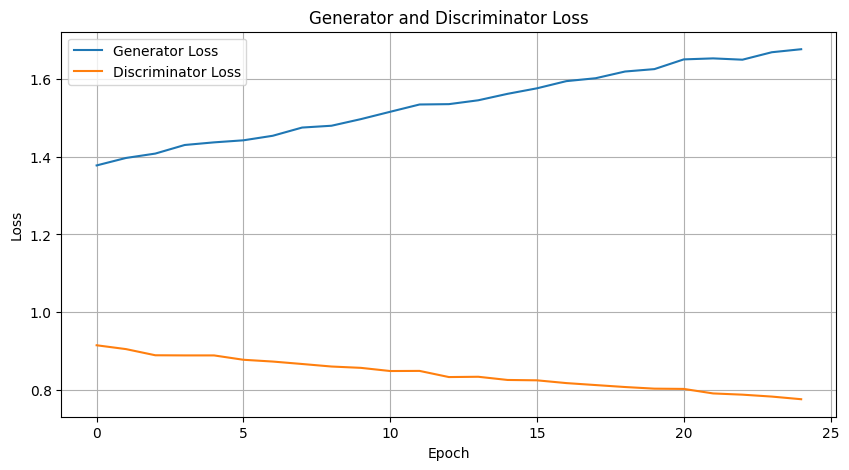

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss")

plt.legend()
plt.grid()

plt.show()

# Analysis

## 1. How do the images change from Epoch 5 to Epoch 25?

At Epoch 5, the generated images are still relatively noisy and clothing shapes are not very clear. As training progresses, the Generator learns more meaningful patterns from the Fashion-MNIST dataset. By Epoch 25, the generated images generally contain clearer and more recognizable clothing-like structures.

## 2. Can instability in training be observed?

GAN training can be unstable because the Generator and Discriminator are competing against each other. Changes in the Generator and Discriminator losses can be observed throughout training rather than both losses continuously decreasing.

The loss graph should be examined to determine whether there are large fluctuations or sudden changes in the losses.

## 3. At which epoch do cloth-like shapes become recognizable?

The generated images should be compared at Epochs 5, 10, 15, 20 and 25. The epoch at which recognizable clothing shapes first appear should be identified from the generated image grids.

For example:

"Recognizable clothing-like shapes begin to appear around Epoch __."

The exact epoch depends on the training run.

## 4. Does the image quality continue improving throughout training?

Image quality generally improves during the earlier stages of training. However, the improvement may slow down at later epochs. The generated images from Epoch 20 and Epoch 25 should be compared to determine whether there is still a noticeable improvement.

If the images at the later epochs look very similar, it suggests that the improvement has started to plateau.